In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)

## 1. General overview of data and problem statement

In [4]:
training_data = pd.read_csv("datasets/house_prices_dataset/train.csv")

In [5]:
training_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
training_data.shape

(1460, 81)

In [7]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
# Verify amount of null values per column
nan_row_info = training_data.isna().sum().sort_values(ascending=True)
nan_row_info[nan_row_info > 0]

Electrical         1
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
BsmtFinType2      38
BsmtExposure      38
GarageQual        81
GarageFinish      81
GarageYrBlt       81
GarageType        81
GarageCond        81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

In [9]:
# Verify amount of null values in terms of percentage
nan_row_info[nan_row_info > 0] / training_data.shape[0] *100

Electrical       0.068493
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtFinType2     2.602740
BsmtExposure     2.602740
GarageQual       5.547945
GarageFinish     5.547945
GarageYrBlt      5.547945
GarageType       5.547945
GarageCond       5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
MasVnrType      59.726027
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

In [10]:
# General info about the data behavior
training_data.describe(include=[np.int64]) # Some of them may be categorical, but expressed as integers

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,10516.828082,6.099315,5.575342,1971.267808,1984.865753,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,9981.264932,1.382997,1.112799,30.202904,20.645407,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [11]:
training_data.describe(include=[str])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


In [12]:
# Verify how many columns are of dtype=str
training_data.describe(include=[str]).shape[1]

43

In [13]:
# Verify Id column
training_data.Id.value_counts()

Id
1       1
2       1
3       1
4       1
5       1
       ..
1456    1
1457    1
1458    1
1459    1
1460    1
Name: count, Length: 1460, dtype: int64

In [14]:
# Verify uniqueness of Id column
training_data.Id.value_counts()[training_data.Id.value_counts() != 1]

Series([], Name: count, dtype: int64)

In [15]:
# Verify duplicates (without considering the null values)
print(training_data.shape)
print(training_data.drop(columns=["Id"]).drop_duplicates().shape)

(1460, 81)
(1460, 80)


### Observations
#### - 1460 rows: Probably not big enough to justify a complicated model like a neural network
#### - Fence, Alley, MiscFeature and PoolQC have more than 80% null data. These features should be verified in the EDA to determine whether to keep them or not. And if we keep some feature with null values, we must determine how to transform those null values, depending on the general behavior of the data.
#### - MasVnrType has a lower percentage of null values, but it's almost 60%. And FireplaceQu has almost 50% null values. Those features need to be verified also.
#### - For the other features with lower percentages of nulls, these need to be verified but there is a lower probability that these features may be dropped due to low amount of null values
#### - The Id column may probably be dropped, since it's basically behaving like an index with no useful information for house prices prediction.
#### - No duplicates for now, regardless of whether the Id column is considered or not. However, more verification is needed since it's possible that some rows may have very similar values and thus possibly represent the same data point.
#### - Various numerical columns have a high standard deviation relative to the mean. For example: some variables have a standard deviation higher than the mean. Others have a standard deviation close in magnitude to the mean. Therefore, histogram analysis is needed for sure.
#### - A lot of variables will have a high magnitude skew, since various variables have the min and the lower percentiles as zero, while the higher percentages have a much higher magnitude. It's possible that some nonlinear transformation is needed. But that will be determined during EDA.
#### - More than half of the features are categorical features (43) than numerical features.
#### - Some categorical features are highly skewed, since for some of them, one category appears in more than 1000 rows. Therefore, the data is imbalanced for various features. These features need to be verified. If a categorical feature is almost completely dominated by one category (example: more than 90% of the rows corresponds to one category), the model may not learn enough patterns to determine how that feature affects the target variable. Therefore, some features may be dropped during data cleaning section due to this. But more verification is needed.
#### - Some anomaly detection may be necessary, especially for highly skewed features
#### - Since there are a lot of features, we can use techniques like correlation matrix, scatter plots and clustering to determine if some features are redundant. Or we can use L1 regularization so that the model can determine which are the most important features. Or a combination of both approaches.

#### - Target variable: The mean and standard deviation are ~180,000 and ~80,000, respectively. The standard deviation is 44% of the mean, so there is a lot of fluctuation in the data. Some verification is needed to verify the skew of the target variable

## Problem statement
#### - Type of problem: 
##### -- Regression (since the target column SalePrice is a numerical column and continuous)
#### - Possible models to consider: 
##### -- Linear regression, polynomial regression, random forest regressor, xgboost
#### - Model Metrics:
##### -- Mean squared error
#### - Baseline performance: 
##### -- None for now
#### - Who may use a model like this: 
##### -- Customers that may be interested in buying a house. In this case, we would need to keep the model simple and possibly focus on a low amount of features to increase interpretability, since general customers may not be interested in many details.
##### -- House prices experts: In this case, keeping as many features as possible would be necessary since one may be focused on the details, but probably not too many features depending on the mathematical background that one may have.
##### -- Statisticians: In this case, keeping as many features as possibles may be useful since one may be interested in a more complex model



## 2. EDA

### General EDA

In [16]:
training_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
# Let's verify null values

In [18]:
training_data.isna().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [19]:
training_data.isna().sum().sort_values(ascending=False).head(20) / training_data.shape[0] * 100

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Id               0.000000
dtype: float64

In [20]:
training_data.shape[0]

1460

### Distribution of target variable

In [21]:
number_of_bins = int(training_data.shape[0] / 10)
number_of_bins

146

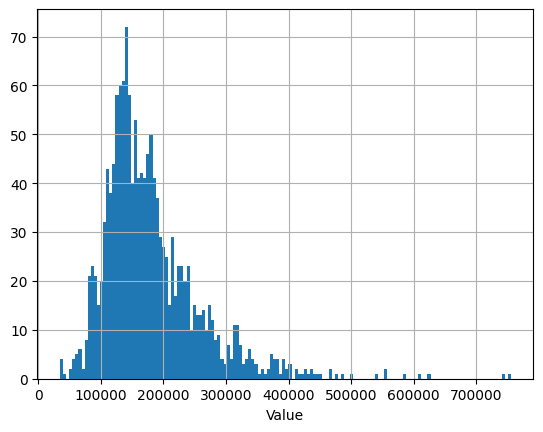

In [22]:
# Distribution of target variable
training_data["SalePrice"].hist(bins=number_of_bins)
plt.xlabel("Value")
plt.show()

In [23]:
float(training_data["SalePrice"].skew())

1.8828757597682129

In [24]:
training_data["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

### Verify for possible outliers

In [25]:
for value in range(10):
    percentile = 0.90 + value/100
    print(f"{percentile*100}th percentile: ", float(training_data["SalePrice"].quantile(percentile)))

90.0th percentile:  278000.0
91.0th percentile:  285000.0
92.0th percentile:  295914.95999999996
93.0th percentile:  311305.0000000002
94.0th percentile:  318028.06
95.0th percentile:  326100.00000000035
96.0th percentile:  344151.4799999997
97.0th percentile:  374230.0
98.0th percentile:  394931.06
99.0th percentile:  442567.01000000053


In [26]:
for value in range(10):
    percentile = 0.99 + value/1000
    print(f"{percentile*100}th percentile: ", float(training_data["SalePrice"].quantile(percentile)))

99.0th percentile:  442567.01000000053
99.1th percentile:  451204.7409999995
99.2th percentile:  465491.99999999994
99.3th percentile:  473189.5000000003
99.4th percentile:  489141.9020000016
99.5th percentile:  527331.9149999974
99.6th percentile:  555259.284
99.7th percentile:  572998.2960000013
99.8th percentile:  612751.1260000014
99.9th percentile:  689919.9999999928


In [27]:
training_data["SalePrice"].quantile(0.98)

np.float64(394931.06)

### Observations

#### - The behavior of the target variable SalePrice is not perfectly gaussian. Currently it is right skewed, since 90% of the values range from 34900 to ~27800, while the remaining 10% have a wider gap between ~27800 and ~75500
#### - Therefore, a nonlinear transformation could be apply to this variable to allow the model to generalize better
#### - For now, we can use log(x+c), where c is a constant that is minimum zero. One can increase that value until one gets a good enough gaussian behavior

### Distribution of features

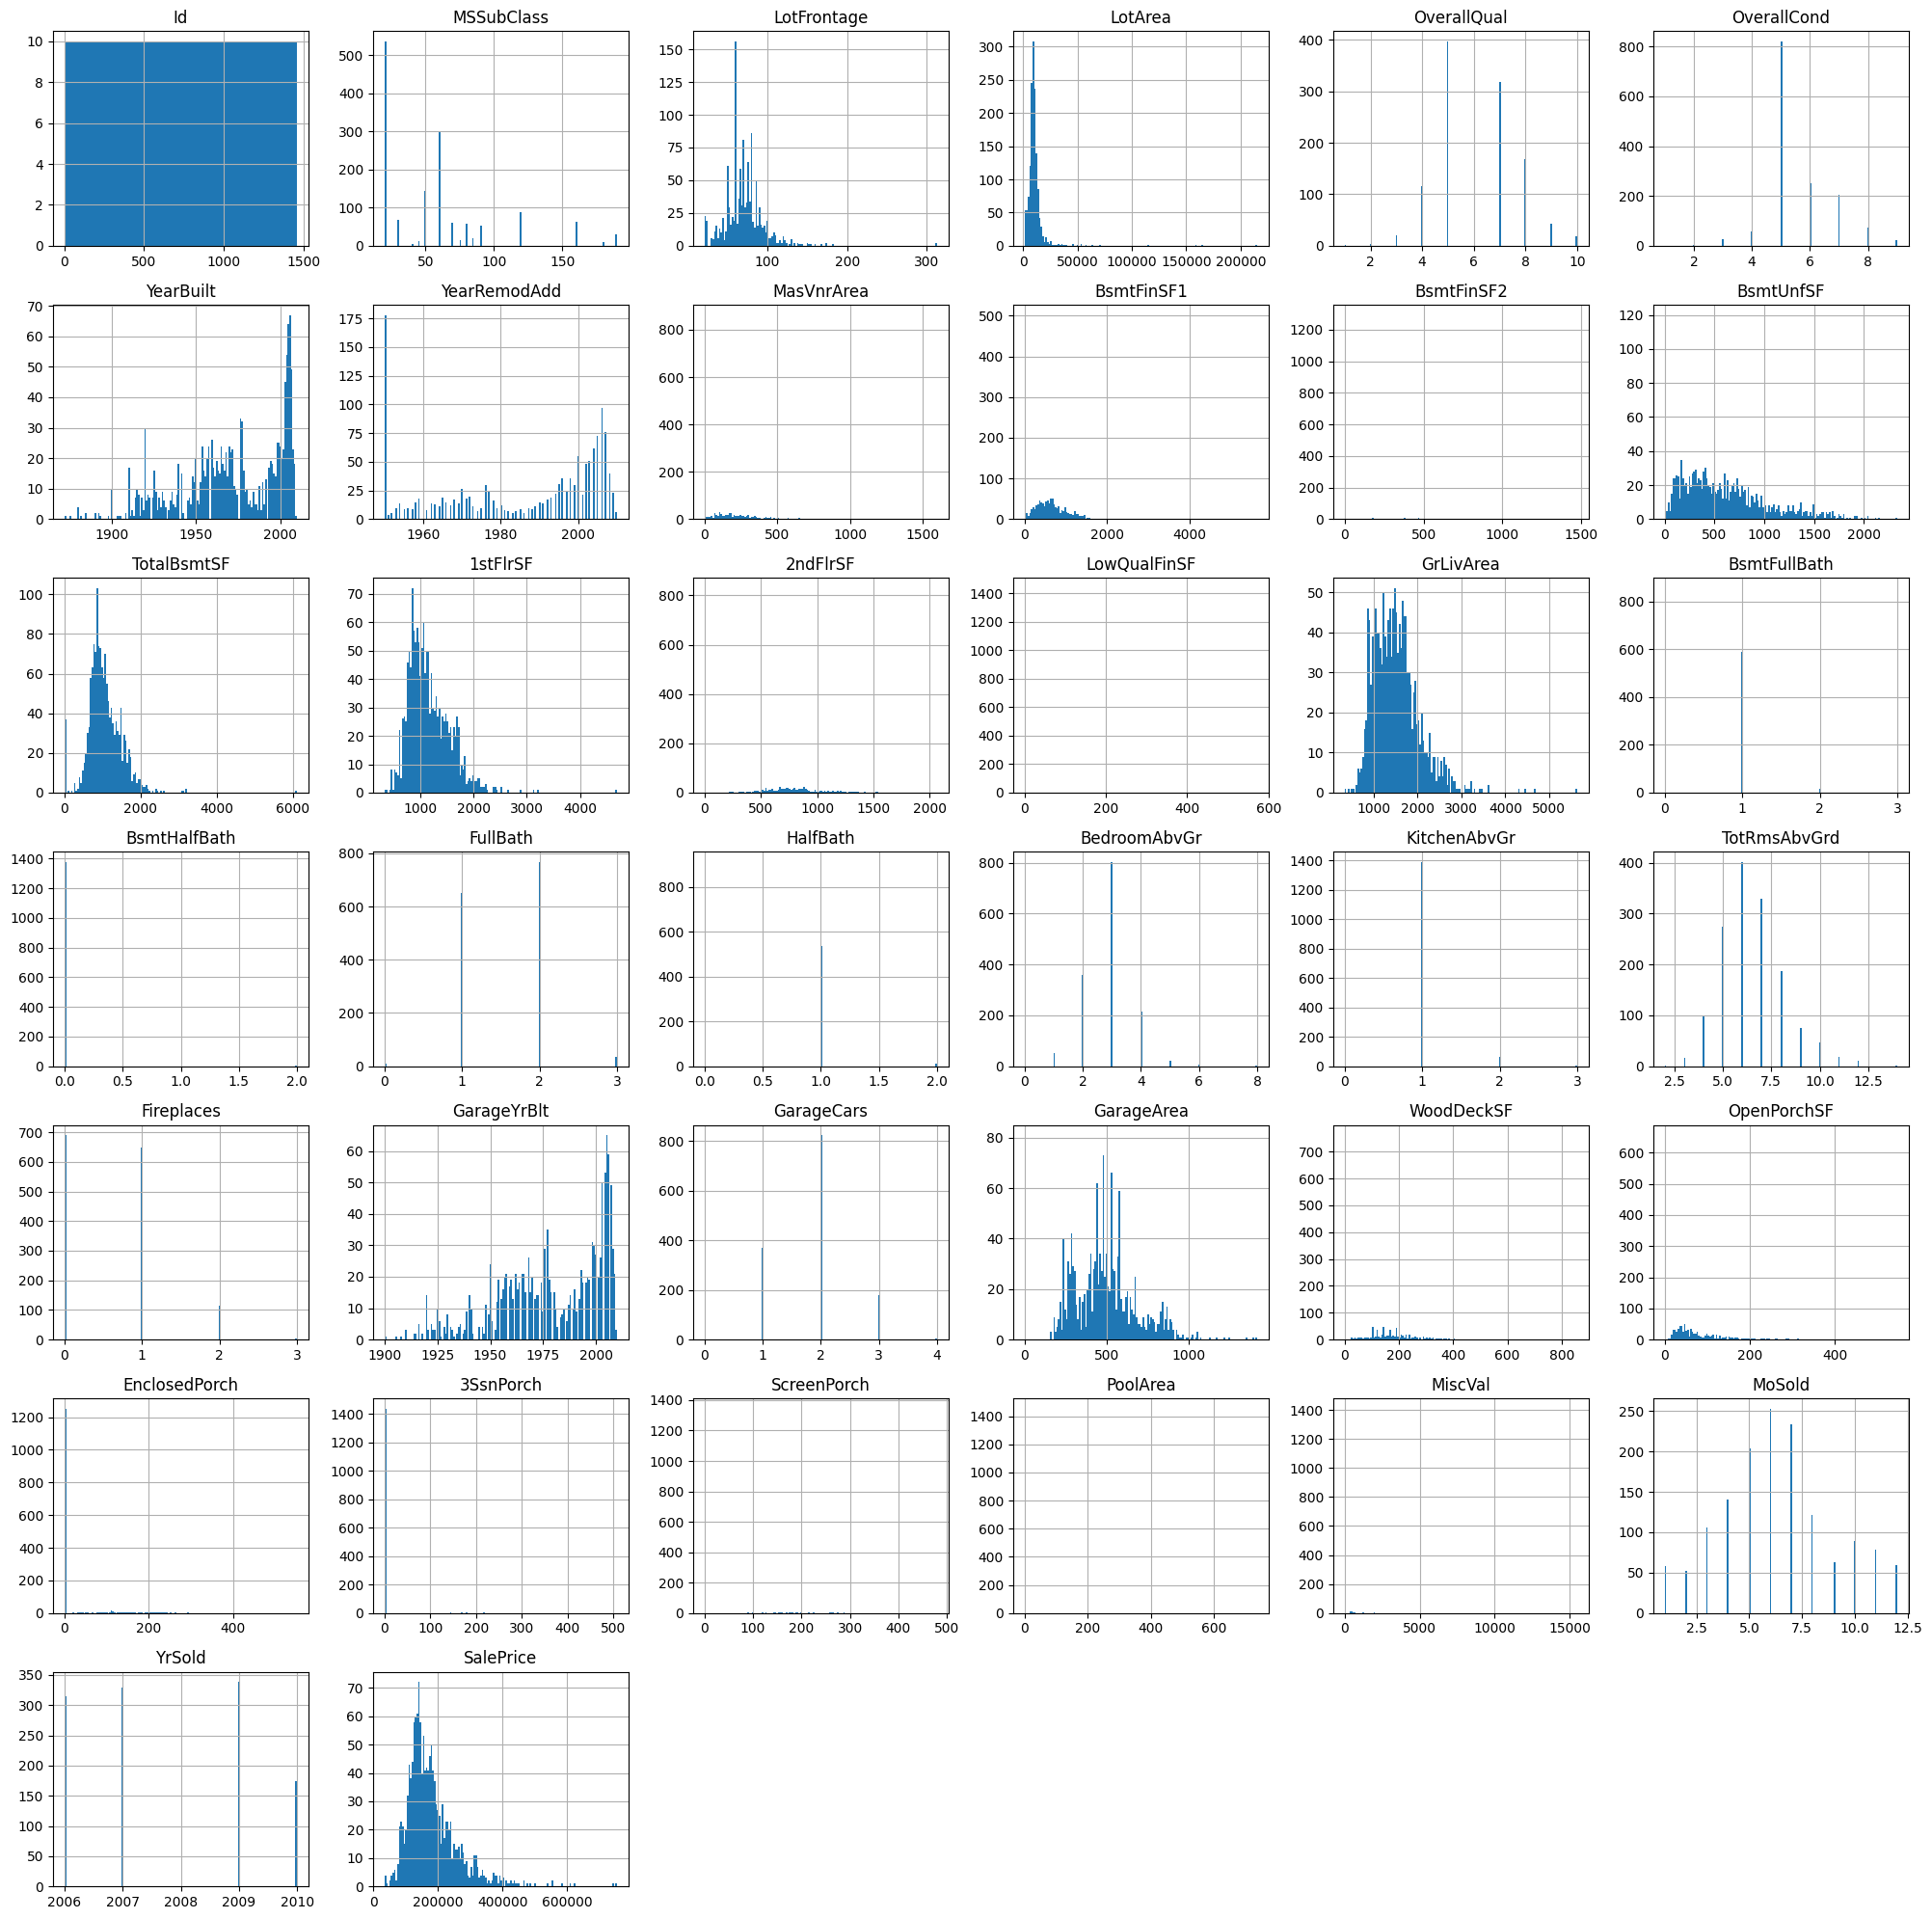

In [28]:
# The majority of the features are integers. However, some of those look categorical. Let's plot the histograms to verify.
training_data.hist(bins=number_of_bins, figsize=(20,20))
plt.tight_layout()
plt.show()

In [29]:
# Let's focus on the features that have the least amount of null values
training_data.isna().sum().sort_values(ascending=True).head(70) / training_data.shape[0] * 100

Id               0.000000
TotalBsmtSF      0.000000
Heating          0.000000
SaleCondition    0.000000
CentralAir       0.000000
                   ...   
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtFinType2     2.602740
BsmtExposure     2.602740
GarageQual       5.547945
Length: 70, dtype: float64

### Observations:
#### The ID has skew=0 and the values are all unique. Thus, it behaves the same as an index column. Therefore, we can remove this column.

#### The following numerical columns look categorical:
####   - OverallQual,OverallCond, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath
#### MoSold looks categorical because, even if it represents a number, it is limited between 1-12.


In [30]:
# Training data for non-numeric columns
training_data.select_dtypes(exclude=[np.number])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,NaN,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,NaN,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,NaN,TA,TA,PConc,Gd,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,Plywood,Plywood,Stone,TA,TA,CBlock,Gd,TA,No,ALQ,Rec,GasA,TA,Y,SBrkr,TA,Min1,TA,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,CemntBd,CmentBd,NaN,Ex,Gd,Stone,TA,Gd,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,TA,TA,Mn,GLQ,Rec,GasA,Gd,Y,FuseA,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [31]:
training_data.select_dtypes(exclude=[np.number]).describe()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


In [32]:
training_data.select_dtypes(exclude=[np.number]).isna().sum()

MSZoning            0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinType2       38
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
KitchenQual         0
Functional          0
FireplaceQu       690
GarageType         81
GarageFinish       81
GarageQual         81
GarageCond         81
PavedDrive          0
PoolQC           1453
Fence            1179
MiscFeature      1406
SaleType            0
SaleCondition       0
dtype: int64

#### Observations
##### - It's hard to determine which features are important for now. Let's perform a correlation matrix analysis

### Correlation matrix

In [33]:
non_numeric_columns = training_data.select_dtypes(exclude=[np.number]).describe().columns.tolist()

In [34]:
for col in non_numeric_columns:
    print(col, ":  ",  training_data[col].fillna("000").unique().tolist())

MSZoning :   ['RL', 'RM', 'C (all)', 'FV', 'RH']
Street :   ['Pave', 'Grvl']
Alley :   ['000', 'Grvl', 'Pave']
LotShape :   ['Reg', 'IR1', 'IR2', 'IR3']
LandContour :   ['Lvl', 'Bnk', 'Low', 'HLS']
Utilities :   ['AllPub', 'NoSeWa']
LotConfig :   ['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
LandSlope :   ['Gtl', 'Mod', 'Sev']
Neighborhood :   ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst', 'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes', 'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU', 'Blueste']
Condition1 :   ['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Condition2 :   ['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe']
BldgType :   ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
HouseStyle :   ['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf', '2.5Fin']
RoofStyle :   ['Gable', 'Hip', 'Gambrel', 'Mansard', 'Flat

In [35]:
for col in non_numeric_columns:
    if "000" in training_data[col].fillna("000").unique().tolist():
        print(col)

Alley
MasVnrType
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Electrical
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PoolQC
Fence
MiscFeature


In [36]:
# Let's use label encoding to transform the non-numeric columns

In [37]:
# Order for label encoding (By changing nan to "000", we ensure that the LabelEncoder picks those values as the first category),
# since the categories are assigned in alphabetical order
mapping = {}
mapping["LotShape"] = ['Reg', 'IR1', 'IR2', 'IR3']
mapping["LandContour"] = ['Lvl', 'Bnk', 'Low', 'HLS']
mapping["Utilities"] = ['NoSeWa', 'AllPub']
mapping["LandSlope"] = ['Gtl', 'Mod', 'Sev']
mapping["Condition1"]= ['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe', 'RRNe']
mapping["Condition2"]= ['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe']
mapping["BldgType"] = ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
mapping["HouseStyle"] = ['SFoyer', 'SLvl', '1Story', '1.5Unf', '1.5Fin', '2Story', '2.5Unf', '2.5Fin']
mapping["Exterior1st"] = ['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'CemntBd', 'Plywood', 'AsbShng', 'Stucco', 'AsphShn', 'Stone', 'ImStucc', 'CBlock', 'WdShing', 'BrkComm', 'Other', 'Brk Cmn', 'Wd Shng']
mapping["Exterior2nd"] = ['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'CmentBd', 'Plywood', 'AsbShng', 'Stucco', 'AsphShn', 'Stone', 'ImStucc', 'CBlock', 'WdShing', 'BrkComm', 'Other', 'Brk Cmn', 'Wd Shng']

mapping["ExterQual"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["ExterCond"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["BsmtQual"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["BsmtCond"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["BsmtExposure"] = ['000', 'No', 'Mn', 'Av', 'Gd']
mapping["BsmtFinType1"] = ['000', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
mapping["BsmtFinType2"] = ['000', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
mapping["HeatingQC"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["CentralAir"] = ['N', 'Y']
mapping["KitchenQual"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["Functional"] = ['Sev', 'Sal', 'Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2']
mapping["FireplaceQu"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

mapping["GarageFinish"] = ['000', 'Unf', 'RFn', 'Fin']
mapping["GarageQual"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["GarageCond"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["PavedDrive"] = ['N', 'P', 'Y']
mapping["PoolQC"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
mapping["Fence"] = ['000', 'MnPrv', 'GdWo', 'MnWw', 'GdPrv']
mapping["MiscFeature"] = ['000', 'Shed', 'Gar2', 'Othr', 'TenC']



In [38]:
training_data_transformed = training_data.copy()
for col in non_numeric_columns:
    print(f"Processing: {col}")
    if col in mapping:
        oe = OrdinalEncoder(categories=[mapping[col]])
    else:
        oe = OrdinalEncoder()
    training_data_transformed[col] = training_data_transformed[col].fillna("000")
    training_data_transformed[col] = oe.fit_transform(training_data_transformed[[col]])

Processing: MSZoning
Processing: Street
Processing: Alley
Processing: LotShape
Processing: LandContour
Processing: Utilities
Processing: LotConfig
Processing: LandSlope
Processing: Neighborhood
Processing: Condition1
Processing: Condition2
Processing: BldgType
Processing: HouseStyle
Processing: RoofStyle
Processing: RoofMatl
Processing: Exterior1st
Processing: Exterior2nd
Processing: MasVnrType
Processing: ExterQual
Processing: ExterCond
Processing: Foundation
Processing: BsmtQual
Processing: BsmtCond
Processing: BsmtExposure
Processing: BsmtFinType1
Processing: BsmtFinType2
Processing: Heating
Processing: HeatingQC
Processing: CentralAir
Processing: Electrical
Processing: KitchenQual
Processing: Functional
Processing: FireplaceQu
Processing: GarageType
Processing: GarageFinish
Processing: GarageQual
Processing: GarageCond
Processing: PavedDrive
Processing: PoolQC
Processing: Fence
Processing: MiscFeature
Processing: SaleType
Processing: SaleCondition


In [39]:
training_data_transformed.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3.0,65.0,8450,1.0,0.0,0.0,0.0,1.0,4.0,0.0,5.0,0.0,0.0,0.0,5.0,7,5,2003,2003,1.0,1.0,0.0,0.0,2.0,196.0,4.0,3.0,2.0,4.0,3.0,1.0,6.0,706,1.0,0,150,856,1.0,5.0,1.0,5.0,856,854,0,1710,1,0,2,1,3,1,4.0,8,2.0,0,0.0,2.0,2003.0,2.0,2,548,3.0,3.0,2.0,0,61,0,0,0,0,0.0,0.0,0.0,0,2,2008,8.0,4.0,208500
1,2,20,3.0,80.0,9600,1.0,0.0,0.0,0.0,1.0,2.0,0.0,24.0,3.0,0.0,0.0,2.0,6,8,1976,1976,1.0,1.0,1.0,1.0,0.0,0.0,3.0,3.0,1.0,4.0,3.0,4.0,5.0,978,1.0,0,284,1262,1.0,5.0,1.0,5.0,1262,0,0,1262,0,1,2,0,3,1,3.0,6,2.0,1,3.0,2.0,1976.0,2.0,2,460,3.0,3.0,2.0,298,0,0,0,0,0,0.0,0.0,0.0,0,5,2007,8.0,4.0,181500
2,3,60,3.0,68.0,11250,1.0,0.0,1.0,0.0,1.0,4.0,0.0,5.0,0.0,0.0,0.0,5.0,7,5,2001,2002,1.0,1.0,0.0,0.0,2.0,162.0,4.0,3.0,2.0,4.0,3.0,2.0,6.0,486,1.0,0,434,920,1.0,5.0,1.0,5.0,920,866,0,1786,1,0,2,1,3,1,4.0,6,2.0,1,3.0,2.0,2001.0,2.0,2,608,3.0,3.0,2.0,0,42,0,0,0,0,0.0,0.0,0.0,0,9,2008,8.0,4.0,223500
3,4,70,3.0,60.0,9550,1.0,0.0,1.0,0.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,5.0,7,5,1915,1970,1.0,1.0,2.0,17.0,0.0,0.0,3.0,3.0,0.0,3.0,4.0,1.0,5.0,216,1.0,0,540,756,1.0,4.0,1.0,5.0,961,756,0,1717,1,0,1,0,3,1,4.0,7,2.0,1,4.0,6.0,1998.0,1.0,3,642,3.0,3.0,2.0,0,35,272,0,0,0,0.0,0.0,0.0,0,2,2006,8.0,0.0,140000
4,5,60,3.0,84.0,14260,1.0,0.0,1.0,0.0,1.0,2.0,0.0,15.0,0.0,0.0,0.0,5.0,8,5,2000,2000,1.0,1.0,0.0,0.0,2.0,350.0,4.0,3.0,2.0,4.0,3.0,3.0,6.0,655,1.0,0,490,1145,1.0,5.0,1.0,5.0,1145,1053,0,2198,1,0,2,1,4,1,4.0,9,2.0,1,3.0,2.0,2000.0,2.0,3,836,3.0,3.0,2.0,192,84,0,0,0,0,0.0,0.0,0.0,0,12,2008,8.0,4.0,250000


In [40]:
len(training_data_transformed.select_dtypes("number").columns)

81

In [41]:
training_data_transformed.dtypes.unique()

array([dtype('int64'), dtype('float64')], dtype=object)

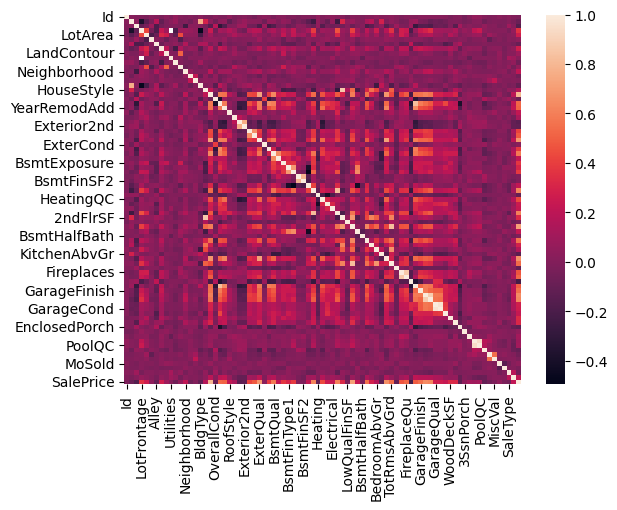

In [42]:
corr_matrix = training_data_transformed.select_dtypes("number").corr()
sns.heatmap(corr_matrix)
plt.show()

In [43]:
# Verify correlation between target variable and the features
corr_matrix[["SalePrice"]]

,SalePrice
Id,-0.021917
MSSubClass,-0.084284
MSZoning,-0.166872
LotFrontage,0.351799
LotArea,0.263843
...,...
MoSold,0.046432
YrSold,-0.028923
SaleType,-0.054911
SaleCondition,0.213092


In [44]:
# Verify the features with the highest magnitude positive correlation with SalePrice
corr_matrix[["SalePrice"]].sort_values(by=["SalePrice"], ascending=False).head(20)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
BsmtQual,0.585207


In [45]:
# Verify the features with the highest magnitude negative correlation with SalePrice
corr_matrix[["SalePrice"]].sort_values(by=["SalePrice"], ascending=True).head(20)

,SalePrice
GarageType,-0.223819
MSZoning,-0.166872
Exterior1st,-0.140954
KitchenAbvGr,-0.135907
EnclosedPorch,-0.128578
Exterior2nd,-0.121259
BldgType,-0.112611
Fence,-0.107893
Functional,-0.104653
Heating,-0.098812


### For now, let's choose the following features (15 for now):

#### "OverallQual": General quality is important for determining price
#### "GrLivArea": Above ground house size also is important
#### "ExterQual": External quality is important
#### "KitchenQual": Kitchen quality is important
#### "GarageCars": Many house customers may prefer garages where they can fit as much cars as possible
#### "GarageArea": We need to do an analysis between this variable and the GarageCars, since they basically represent the size of the garage. Possibly one can keep either GarageArea or GarageCars or both.
#### "TotalBsmtSF": Total basement size is important for the customers that want a basement.
#### "1stFlrSF": May need to determine if this is redundant, given that there is also "GrLivArea". But every home (or mostly every home) will have a first floor, so the size of that floor is important
#### "BsmtQual": Basement quality is important
#### "FullBath": Important since it determines how many full bathrooms have good quality
#### "GarageFinish": Garage quality is important
#### "TotRmsAbvGrd": Total rooms above grade is important
#### "YearBuilt": Some customers may prefer modern houses, while other customers may prefer older and classical style houses
#### "FireplaceQu": May be useful for customers who are interested in fireplace
#### "YearRemodAdd": The YearBuilt feature may not be useful by itself because if the house is in bad conditions, the YearBuilt won't matter much for customers. However, if the YearRemodAdd is not the same as the YearBuilt, then that means that the house had remodelation, which may be relevant since customers may be interested in houses that are modernized. Although that will depend on the quality of the remodeling and how often there was remodeling. The data description doesn't specify whether the year corresponds to the last remodeled year, the first remodeled year, etc. We can verify through the model how relevant is the feature.
#### "HeatingQC": Even if correlation value is lower, the temperature of the house can be important. Possibly, it's more important in extreme temperature conditions (example: very cold weathers or very hot weathers). However, it remains to be seen whether this feature is relevant or not, because we don't know how many of the houses in the data are built on conditions that may require a heater/thermostat. We can keep the feature for now and allow the model to decide if it's a useful feature (by using regularization).


In [46]:
features_to_keep = ["OverallQual", "GrLivArea", "ExterQual", "KitchenQual", "GarageCars",
                    "GarageArea", "TotalBsmtSF", "1stFlrSF", "BsmtQual", "FullBath",
                    "GarageFinish", "TotRmsAbvGrd", "YearBuilt", "FireplaceQu", "YearRemodAdd",
                    "HeatingQC"]

In [47]:
# Let's use the dataframe that has the transformations
training_data_transformed = training_data_transformed[features_to_keep + ["SalePrice"]]

In [48]:
# Verify null values in the remaining columns
training_data_transformed.isna().sum()

OverallQual     0
GrLivArea       0
ExterQual       0
KitchenQual     0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
BsmtQual        0
FullBath        0
GarageFinish    0
TotRmsAbvGrd    0
YearBuilt       0
FireplaceQu     0
YearRemodAdd    0
HeatingQC       0
SalePrice       0
dtype: int64

In [49]:
# Verify for duplicate rows in the remaining rows
print(training_data_transformed.shape)
print(training_data_transformed.drop_duplicates().shape)

(1460, 17)
(1460, 17)


### Histograms for the transformed dataframe

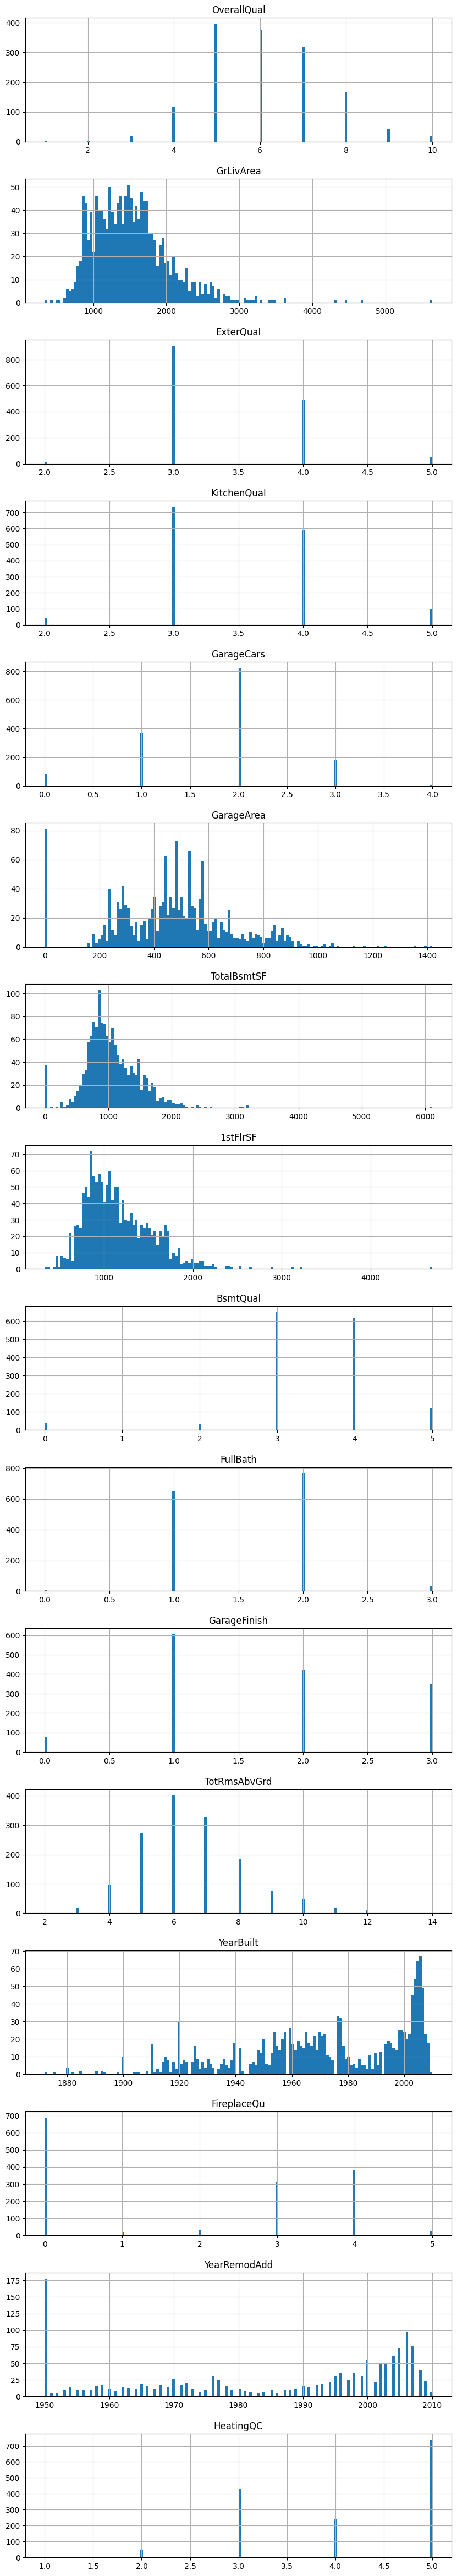

In [50]:
training_data_transformed[features_to_keep].hist(bins=number_of_bins, 
                                                 figsize=(10,60), 
                                                 layout=(len(features_to_keep),1)
                                                )
plt.subplots_adjust()
plt.show()

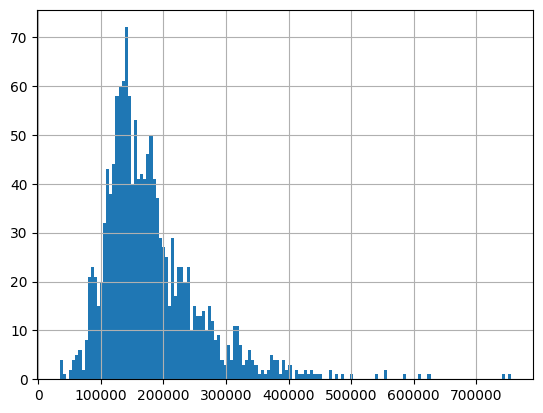

In [51]:
training_data_transformed["SalePrice"].hist(bins=number_of_bins)
plt.show()

#### Observations:
##### - Some features are right-skewed and others are left-skewed.
##### - The target variable SalePrice is right-skewed.

##### Let's verify the skew values.

In [52]:
training_data_transformed.skew().sort_values(ascending=False)

SalePrice       1.882876
TotalBsmtSF     1.524255
1stFlrSF        1.376757
GrLivArea       1.366560
ExterQual       0.825988
TotRmsAbvGrd    0.676341
KitchenQual     0.386765
OverallQual     0.216944
GarageArea      0.179981
GarageFinish    0.119867
FireplaceQu     0.112770
FullBath        0.036562
GarageCars     -0.342549
YearRemodAdd   -0.503562
HeatingQC      -0.540458
YearBuilt      -0.613461
BsmtQual       -1.287571
dtype: float64

In [53]:
training_data_transformed.min()

OverallQual         1.0
GrLivArea         334.0
ExterQual           2.0
KitchenQual         2.0
GarageCars          0.0
GarageArea          0.0
TotalBsmtSF         0.0
1stFlrSF          334.0
BsmtQual            0.0
FullBath            0.0
GarageFinish        0.0
TotRmsAbvGrd        2.0
YearBuilt        1872.0
FireplaceQu         0.0
YearRemodAdd     1950.0
HeatingQC           1.0
SalePrice       34900.0
dtype: float64

In [54]:
training_data_transformed.max()

OverallQual         10.0
GrLivArea         5642.0
ExterQual            5.0
KitchenQual          5.0
GarageCars           4.0
GarageArea        1418.0
TotalBsmtSF       6110.0
1stFlrSF          4692.0
BsmtQual             5.0
FullBath             3.0
GarageFinish         3.0
TotRmsAbvGrd        14.0
YearBuilt         2010.0
FireplaceQu          5.0
YearRemodAdd      2010.0
HeatingQC            5.0
SalePrice       755000.0
dtype: float64

#### Observations
##### - GarageArea has a lot of values as zero. Let's verify what those values mean by verifying the garage-related columns.

In [55]:
training_data_transformed[training_data_transformed.GarageArea ==0]

,OverallQual,GrLivArea,ExterQual,KitchenQual,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,BsmtQual,FullBath,GarageFinish,TotRmsAbvGrd,YearBuilt,FireplaceQu,YearRemodAdd,HeatingQC,SalePrice
39,4,1152,3.0,2.0,0,0,0,1152,0.0,2,0.0,6,1955,0.0,1955,3.0,82000
48,4,1452,3.0,3.0,0,0,736,736,3.0,2,0.0,8,1920,0.0,2008,4.0,113000
78,4,1768,3.0,3.0,0,0,1768,1768,3.0,2,0.0,8,1968,0.0,1968,3.0,136500
88,3,1526,2.0,2.0,0,0,1013,1013,3.0,1,0.0,6,1915,0.0,1982,3.0,85000
89,4,990,3.0,3.0,0,0,990,990,4.0,1,0.0,5,1994,0.0,1995,5.0,123600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349,8,2358,3.0,3.0,0,0,684,938,3.0,2,0.0,8,1872,0.0,1987,2.0,122000
1407,5,833,3.0,3.0,0,0,833,833,3.0,1,0.0,5,1985,0.0,1985,5.0,112000
1449,5,630,3.0,5.0,0,0,630,630,4.0,1,0.0,3,1970,0.0,1970,5.0,92000
1450,5,1792,3.0,3.0,0,0,896,896,4.0,2,0.0,8,1974,0.0,1974,3.0,136000


In [56]:
training_data_transformed[training_data_transformed.GarageCars == 0][
                                    ["GarageCars", "GarageArea", "GarageFinish"]
                                ].drop_duplicates(ignore_index=True)

,GarageCars,GarageArea,GarageFinish
0,0,0,0.0


In [57]:
training_data_transformed[training_data_transformed.GarageArea == 0][
                                    ["GarageCars", "GarageArea", "GarageFinish"]
                                ].drop_duplicates(ignore_index=True)

,GarageCars,GarageArea,GarageFinish
0,0,0,0.0


In [58]:
training_data_transformed[training_data_transformed.GarageFinish == 0][
                                    ["GarageCars", "GarageArea", "GarageFinish"]
                                ].drop_duplicates(ignore_index=True)

,GarageCars,GarageArea,GarageFinish
0,0,0,0.0


In [59]:
training_data_transformed[training_data_transformed.GarageFinish == 0].shape[0] / training_data_transformed.shape[0] * 100

5.5479452054794525

#### Observations:
##### - It seems that the three garage-related variables are consistent. If one of them are zero, then the other two are zero.
##### - This indicates that if one of the variables are zero, then there is no garage.

##### - Therefore, these zero values make sense. If a nonlinear transformation is applied to GarageArea, it needs to be one that doesn't diverge at x=0 (example: Cannot use log(x))

#### Let's do a similar verification for the basement-related features

In [60]:
training_data_transformed[training_data_transformed.TotalBsmtSF == 0][
                                    ["TotalBsmtSF", "BsmtQual"]
                                ].drop_duplicates(ignore_index=True)

,TotalBsmtSF,BsmtQual
0,0,0.0


In [61]:
training_data_transformed[training_data_transformed.BsmtQual == 0][
                                    ["TotalBsmtSF", "BsmtQual"]
                                ].drop_duplicates(ignore_index=True)

,TotalBsmtSF,BsmtQual
0,0,0.0


#### If one of the two above variables is zero, then there is no basement, it seems. So for now, we can keep those rows where the value is zero.

### Multicollinearity analysis

#### Correlation matrix (only for the features)

In [62]:
training_data_transformed.columns

Index(['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'GarageCars',
       'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtQual', 'FullBath',
       'GarageFinish', 'TotRmsAbvGrd', 'YearBuilt', 'FireplaceQu',
       'YearRemodAdd', 'HeatingQC', 'SalePrice'],
      dtype='str')

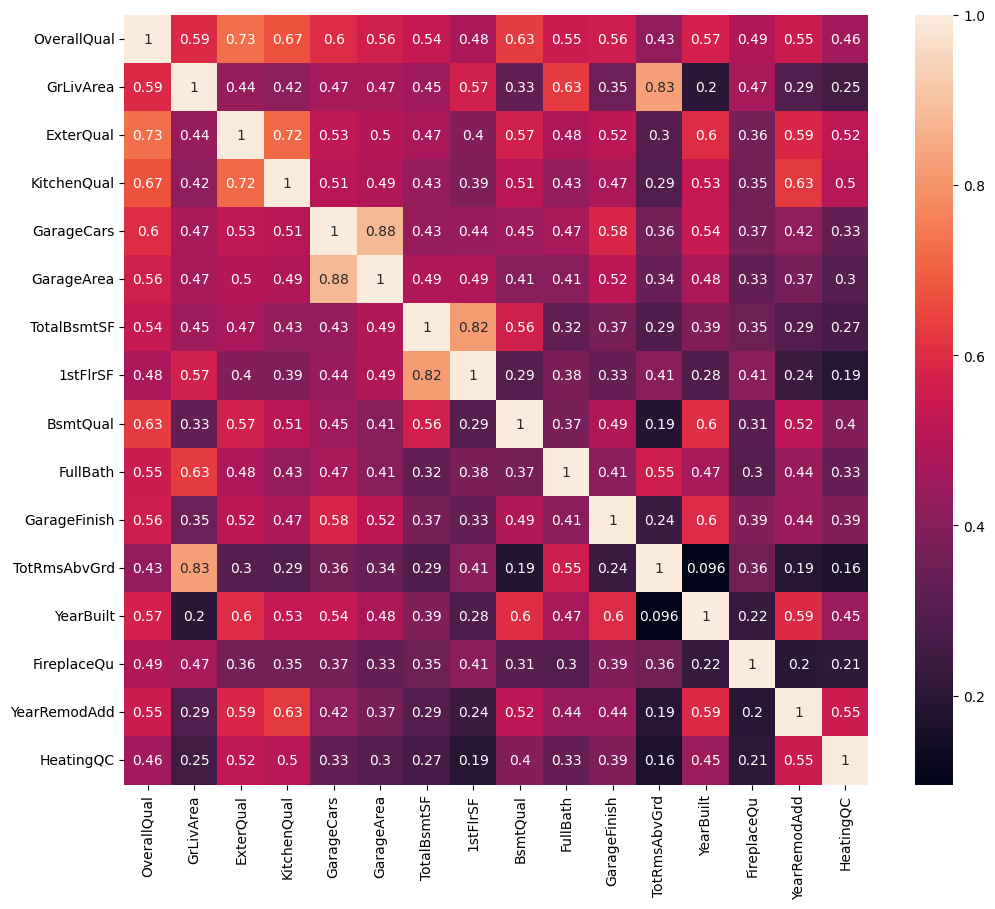

In [63]:
corr_matrix = training_data_transformed[[
                                            'OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'GarageCars',
                                            'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtQual', 'FullBath',
                                            'GarageFinish', 'TotRmsAbvGrd', 'YearBuilt', 'FireplaceQu',
                                            'YearRemodAdd', 'HeatingQC']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True)
plt.show()

#### High correlations found include the following:

##### - GarageCars - GarageArea: 0.88
##### - GrLivArea - TotRmsAbvGrd: 0.83
##### - 1stFlrSF - TotalBsmtSF: 0.82
##### - ExterQual - KitchenQual: 0.72
##### - OverallQual - ExternalQual: 0.73
##### - OverallQual - KitchenQual: 0.67

#### Perform scatter plots to verify relationship between variables

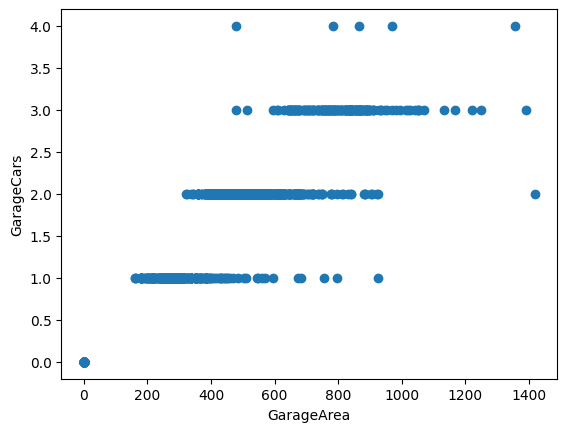

In [64]:
plt.scatter(training_data_transformed["GarageArea"], training_data_transformed["GarageCars"])
plt.xlabel("GarageArea")
plt.ylabel("GarageCars")
plt.show()

#### Observations:
##### - No clear dependency between GarageArea and GarageCars.
##### - It seems that GarageCars doesn't always increase with GarageArea.
##### - We can keep both features for now, and allow the model to decide how important are the features.

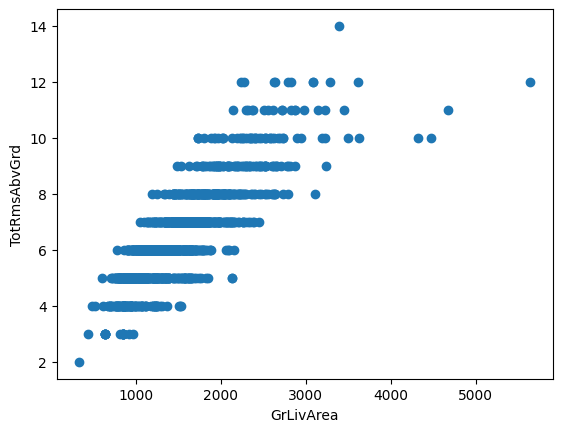

In [65]:
# GrLivArea - TotRmsAbvGrd
plt.scatter(training_data_transformed["GrLivArea"], training_data_transformed["TotRmsAbvGrd"])
plt.xlabel("GrLivArea")
plt.ylabel("TotRmsAbvGrd")
plt.show()

#### Observations:
##### - No clear linear dependency either. We can keep both features for now.

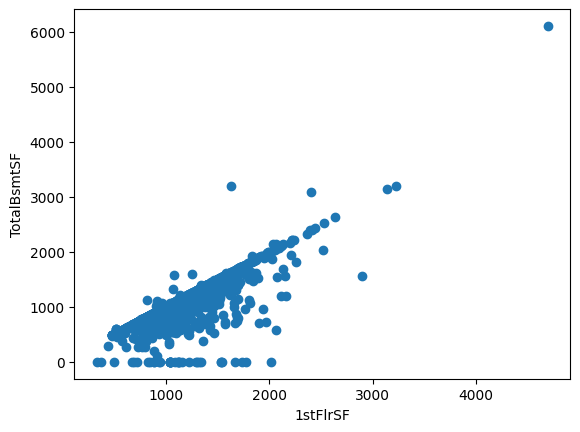

In [66]:
# 1stFlrSF - TotalBsmtSF
plt.scatter(training_data_transformed["1stFlrSF"], training_data_transformed["TotalBsmtSF"])
plt.xlabel("1stFlrSF")
plt.ylabel("TotalBsmtSF")
plt.show()

#### Observations:
##### - No clear linear dependency either. We can keep both features for now.

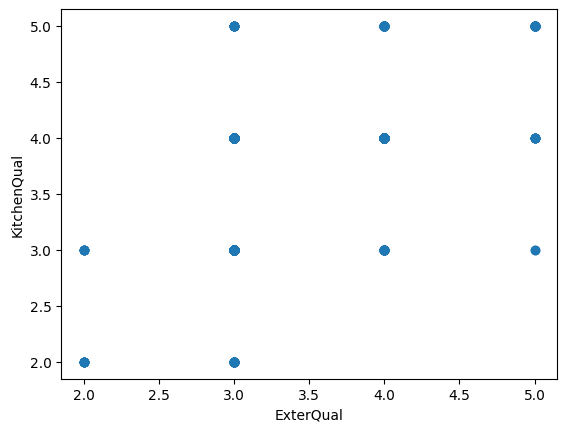

In [67]:
# ExterQual - KitchenQual
plt.scatter(training_data_transformed["ExterQual"], training_data_transformed["KitchenQual"])
plt.xlabel("ExterQual")
plt.ylabel("KitchenQual")
plt.show()

#### Observations:
##### - No clear linear dependency either. We can keep both features for now.

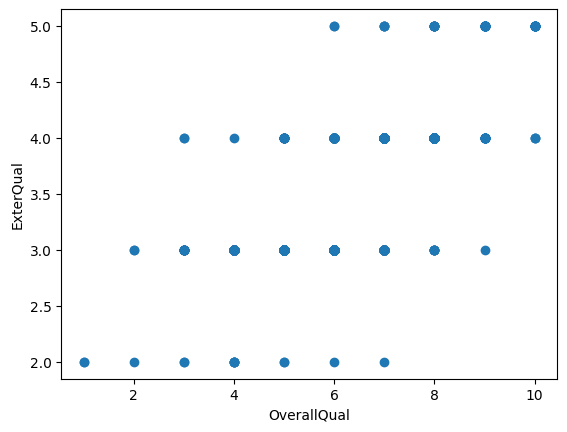

In [68]:
# OverallQual - ExterQual
plt.scatter(training_data_transformed["OverallQual"], training_data_transformed["ExterQual"])
plt.xlabel("OverallQual")
plt.ylabel("ExterQual")
plt.show()

#### Observations:
##### - No clear linear dependency either. We can keep both features for now.

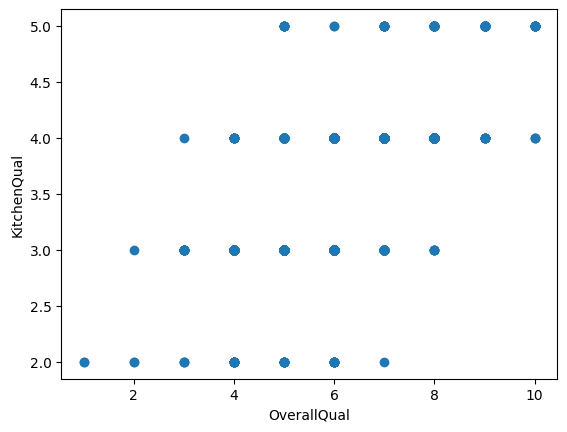

In [69]:
# OverallQual - KitchenQual
plt.scatter(training_data_transformed["OverallQual"], training_data_transformed["KitchenQual"])
plt.xlabel("OverallQual")
plt.ylabel("KitchenQual")
plt.show()

#### Observations:
##### - No clear linear dependency either. We can keep both features for now.

## 3. Data cleaning

### Data cleaning for training data

In [70]:
training_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [71]:
def keep_relevant_cols(df: pd.Dataframe) -> pd.Dataframe:
    return df[features_to_keep + ["SalePrice"]]

def encode_non_numeric_cols(df: pd.Dataframe) -> pd.Dataframe:
    final_mapping = {}
    final_mapping["BsmtQual"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
    final_mapping["GarageFinish"] = ['000', 'Unf', 'RFn', 'Fin']
    final_mapping["FireplaceQu"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
    final_mapping["KitchenQual"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
    final_mapping["ExterQual"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
    final_mapping["HeatingQC"] = ['000', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
    for col in final_mapping.keys():
        print(f"Processing: {col}")
        if col in final_mapping:
            oe = OrdinalEncoder(categories=[final_mapping[col]])
        else:
            oe = OrdinalEncoder()
        df[col] = df[col].fillna("000")
        df[col] = oe.fit_transform(df[[col]])
    return df

In [72]:
training_data_cleaned = keep_relevant_cols(training_data)
training_data_cleaned = encode_non_numeric_cols(training_data_cleaned)

Processing: BsmtQual
Processing: GarageFinish
Processing: FireplaceQu
Processing: KitchenQual
Processing: ExterQual
Processing: HeatingQC


In [73]:
training_data_cleaned.head()

,OverallQual,GrLivArea,ExterQual,KitchenQual,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,BsmtQual,FullBath,GarageFinish,TotRmsAbvGrd,YearBuilt,FireplaceQu,YearRemodAdd,HeatingQC,SalePrice
0,7,1710,4.0,4.0,2,548,856,856,4.0,2,2.0,8,2003,0.0,2003,5.0,208500
1,6,1262,3.0,3.0,2,460,1262,1262,4.0,2,2.0,6,1976,3.0,1976,5.0,181500
2,7,1786,4.0,4.0,2,608,920,920,4.0,2,2.0,6,2001,3.0,2002,5.0,223500
3,7,1717,3.0,4.0,3,642,756,961,3.0,1,1.0,7,1915,4.0,1970,4.0,140000
4,8,2198,4.0,4.0,3,836,1145,1145,4.0,2,2.0,9,2000,3.0,2000,5.0,250000


### Histograms

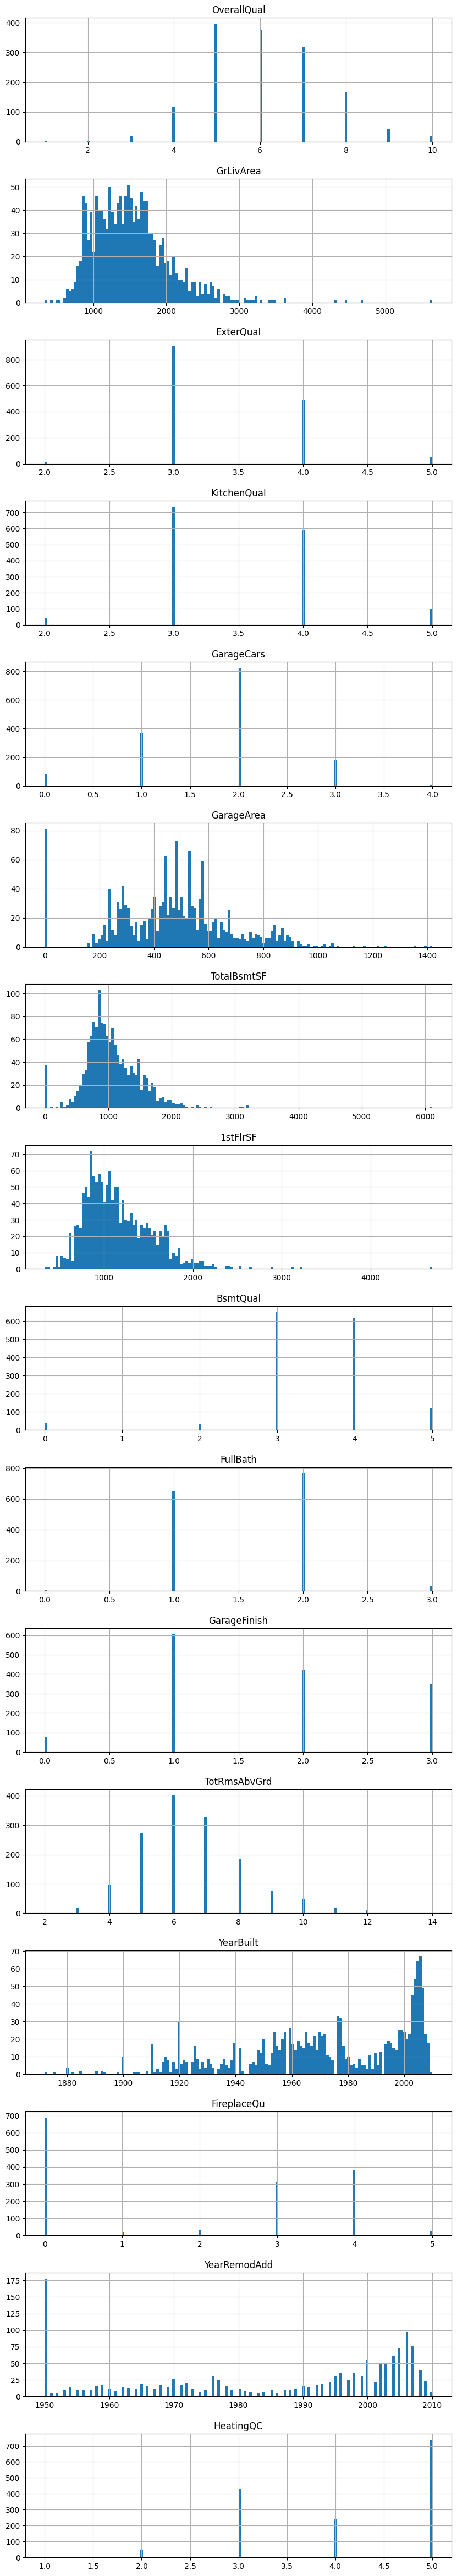

In [74]:
# Features
training_data_cleaned[features_to_keep].hist(bins=number_of_bins, 
                           figsize=(10,60), 
                           layout=(len(features_to_keep),1)
                          )
plt.subplots_adjust()
plt.show()

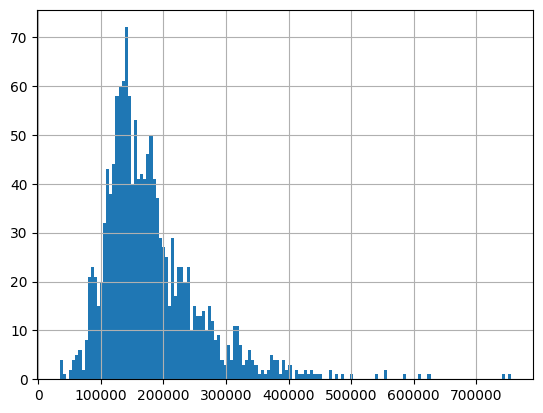

In [75]:
# Target variable
training_data_cleaned["SalePrice"].hist(bins=number_of_bins)
plt.subplots_adjust()
plt.show()

In [76]:
training_data_cleaned.skew().sort_values()

BsmtQual       -1.287571
YearBuilt      -0.613461
HeatingQC      -0.540458
YearRemodAdd   -0.503562
GarageCars     -0.342549
FullBath        0.036562
FireplaceQu     0.112770
GarageFinish    0.119867
GarageArea      0.179981
OverallQual     0.216944
KitchenQual     0.386765
TotRmsAbvGrd    0.676341
ExterQual       0.825988
GrLivArea       1.366560
1stFlrSF        1.376757
TotalBsmtSF     1.524255
SalePrice       1.882876
dtype: float64

#### Observations:
##### - Even if GarageArea has a low skew, there seems to be a lot of values close to zero
##### - YearRemodAdd has a lot of values near 1950, so this may need verification
##### - YearBuilt doesn't look evenly distributed, even if the skew is low

##### - We can apply nonlinear transformation to the following: SalePrice, TotalBsmtSF, 1stFlrSF, GrLivArea, YearRemodAdd, YearBuilt

In [77]:
training_data_cleaned.min().sort_values()

BsmtQual            0.0
FireplaceQu         0.0
GarageFinish        0.0
FullBath            0.0
GarageCars          0.0
GarageArea          0.0
TotalBsmtSF         0.0
HeatingQC           1.0
OverallQual         1.0
KitchenQual         2.0
ExterQual           2.0
TotRmsAbvGrd        2.0
GrLivArea         334.0
1stFlrSF          334.0
YearBuilt        1872.0
YearRemodAdd     1950.0
SalePrice       34900.0
dtype: float64

### Nonlinear transformation

In [78]:
def apply_log_x_transform(df: pd.Dataframe) -> pd.Dataframe:
    for col in ["SalePrice", "1stFlrSF", "GrLivArea", "YearRemodAdd", "YearBuilt"]:
        df[col] = np.log(df[col])
    return df

def apply_log_x_plus_c_transform(df: pd.Dataframe) -> pd.Dataframe:
    c = 1
    col = "TotalBsmtSF"
    df[col] = np.log(df[col] + 1)
    return df

In [79]:
training_data_cleaned = apply_log_x_transform(training_data_cleaned)
training_data_cleaned = apply_log_x_plus_c_transform(training_data_cleaned)

In [80]:
# Let's verify how the histograms changed after nonlinear transform

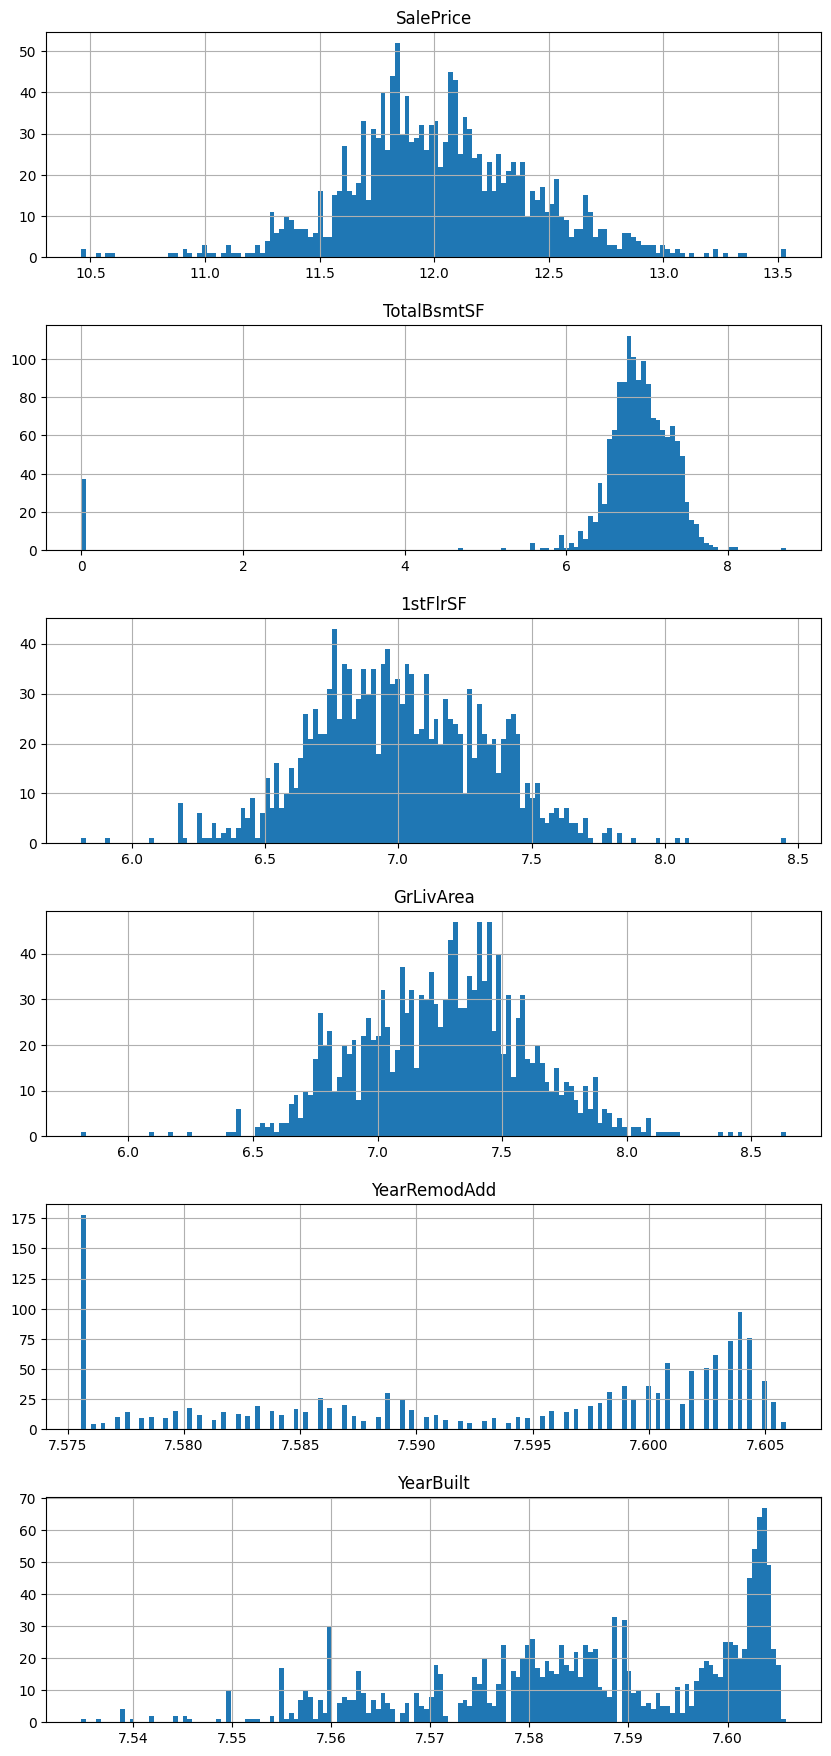

In [81]:
training_data_cleaned[["SalePrice", "TotalBsmtSF", "1stFlrSF", "GrLivArea", "YearRemodAdd", "YearBuilt"]
                                ].hist(bins=number_of_bins,
                                       figsize=(10,60), 
                                       layout=(len(features_to_keep),1)
                                      )
plt.subplots_adjust()
plt.show()

In [82]:
training_data_cleaned.skew()

OverallQual     0.216944
GrLivArea      -0.006995
ExterQual       0.825988
KitchenQual     0.386765
GarageCars     -0.342549
GarageArea      0.179981
TotalBsmtSF    -5.154670
1stFlrSF        0.079157
BsmtQual       -1.287571
FullBath        0.036562
GarageFinish    0.119867
TotRmsAbvGrd    0.676341
YearBuilt      -0.641144
FireplaceQu     0.112770
YearRemodAdd   -0.511009
HeatingQC      -0.540458
SalePrice       0.121335
dtype: float64

#### Observations:
##### There seem to be outliers in TotalBsmtSF and YearRemodAdd. We can keep them for now and verify how the model performs.

## 4. Model

In [83]:
training_data_cleaned.head()

,OverallQual,GrLivArea,ExterQual,KitchenQual,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,BsmtQual,FullBath,GarageFinish,TotRmsAbvGrd,YearBuilt,FireplaceQu,YearRemodAdd,HeatingQC,SalePrice
0,7,7.444249,4.0,4.0,2,548,6.753438,6.752270,4.0,2,2.0,8,7.602401,0.0,7.602401,5.0,12.247694
1,6,7.140453,3.0,3.0,2,460,7.141245,7.140453,4.0,2,2.0,6,7.588830,3.0,7.588830,5.0,12.109011
2,7,7.487734,4.0,4.0,2,608,6.825460,6.824374,4.0,2,2.0,6,7.601402,3.0,7.601902,5.0,12.317167
3,7,7.448334,3.0,4.0,3,642,6.629363,6.867974,3.0,1,1.0,7,7.557473,4.0,7.585789,4.0,11.849398
4,8,7.695303,4.0,4.0,3,836,7.044033,7.043160,4.0,2,2.0,9,7.600902,3.0,7.600902,5.0,12.429216


In [84]:
training_data_cleaned.shape[0]

1460

#### Note:
##### - For now, since the test data is unlabeled, we will use the same training data to create the validation set and the test set. Once test data is available with labels, then that test data will be used to create the validation set and the test set (since the validation set and test set must reflect real-world scenarios, if possible) 

In [85]:
# 60% training, 20% validation, 20% test

X_train, X_val_test, y_train, y_val_test = train_test_split(training_data_cleaned[features_to_keep], 
                                                            training_data_cleaned["SalePrice"],
                                                            test_size = 0.4, 
                                                            random_state=5)

X_val, X_test, y_val, y_test = train_test_split(X_val_test, 
                                                y_val_test,
                                                test_size = 0.5, 
                                                random_state=10)

In [86]:
# Verify if z-score (if needed)

In [87]:
training_data_cleaned.max() - training_data_cleaned.min()

OverallQual        9.000000
GrLivArea          2.826853
ExterQual          3.000000
KitchenQual        3.000000
GarageCars         4.000000
GarageArea      1418.000000
TotalBsmtSF        8.717846
1stFlrSF           2.642473
BsmtQual           5.000000
FullBath           3.000000
GarageFinish       3.000000
TotRmsAbvGrd      12.000000
YearBuilt          0.071127
FireplaceQu        5.000000
YearRemodAdd       0.030305
HeatingQC          4.000000
SalePrice          3.074231
dtype: float64

In [88]:
# We can apply z-score to GarageArea for now

In [89]:
scaler = StandardScaler()

In [90]:
X_train_with_z_score = X_train.copy()
X_train_with_z_score["GarageArea"] = scaler.fit_transform(pd.DataFrame(X_train["GarageArea"]))

In [91]:
X_train_with_z_score["GarageArea"].max() - X_train_with_z_score["GarageArea"].min()

np.float64(6.54309797591567)

### Linear regression

In [92]:
# Train model

In [93]:
model = LinearRegression()
model.fit(X_train_with_z_score, y_train);

In [94]:
model.coef_

array([ 0.07394501,  0.32238818, -0.00684394,  0.05076116,  0.04699101,
        0.01292778,  0.00850351,  0.176388  ,  0.04120675, -0.01127206,
        0.00892431,  0.00291457,  2.62602903,  0.01831312,  2.19300068,
        0.01667468])

In [95]:
list(model.coef_).index(max(model.coef_))

12

In [96]:
features_to_keep[12]

'YearBuilt'

In [97]:
features_to_keep[14]

'YearRemodAdd'

#### Observations:
##### - It seems that YearBuilt and YearRemodAdd have the highest weight parameters.
##### - However, additional EDA is probably needed to analyze correlation between these variables 

In [98]:
model.intercept_

np.float64(-29.139110242262895)

In [99]:
# Training error

In [100]:
y_train_pred = model.predict(X_train_with_z_score)

In [101]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_train

0.024703610301239184

In [102]:
# Validation

In [103]:
X_val_with_z_score = X_val.copy()
X_val_with_z_score["GarageArea"] = scaler.transform(pd.DataFrame(X_val["GarageArea"]))

In [104]:
y_val_pred = model.predict(X_val_with_z_score)

In [105]:
mse_val = mean_squared_error(y_val, y_val_pred)
mse_val

0.02005777860129903

#### Observations:
##### -  The error is similar to the training set

In [106]:
# Test

In [107]:
X_test_with_z_score = X_test.copy()
X_test_with_z_score["GarageArea"] = scaler.transform(pd.DataFrame(X_test["GarageArea"]))

In [108]:
y_test_pred = model.predict(X_test_with_z_score)

In [109]:
mse_test = mean_squared_error(y_test, y_test_pred)
mse_test

0.027460588455654928

In [110]:
# Lowest value of log(SalePrice)
y_test.min()

np.float64(10.460242108190519)

In [111]:
# Highest value of log(SalePrice)
y_test.max()

np.float64(13.345506928718539)

#### Observations:
##### - Error is higher in test set, but very small relative to the magnitude of the transformed target variable, which is log(SalePrice)
##### - The very low magnitude in error is due to nonlinear transformation applied to the target variable, since the log transformation can map the target variable to lower values and create a more uniform distribution
##### - To get the error in terms of the original units of SalePrice, one would need to apply an inverse transformation to the predictions (exponential transformation)


### Random forest regressor

#### Note:
##### -No z-score transformation will be applied here, since tree-based models are not affected by the magnitude of the features. They make decisions on value thresholds, not on distances/magnitudes between data points.

In [112]:
len(features_to_keep)

16

In [113]:
# Using max_depth=3 and max_features=8 to reduce the risk of overfitting

In [114]:
rf_model = RandomForestRegressor(n_estimators=128, 
                                 criterion="squared_error",
                                 max_features=8,
                                 max_depth = 3,
                                 )

In [115]:
rf_model.fit(X_train, y_train);

In [116]:
# Training error

In [117]:
y_train_pred_rf = rf_model.predict(X_train)
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
mse_train_rf

0.03135643984160187

In [118]:
# Validation

In [119]:
y_val_pred_rf = rf_model.predict(X_val)
mse_val_rf = mean_squared_error(y_val, y_val_pred_rf)
mse_val_rf

0.029196212600112563

In [120]:
# Test

In [121]:
y_test_pred_rf = rf_model.predict(X_test)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
mse_test_rf

0.03832896551925756

#### Observations:
##### - Error is higher than in linear regression, especially the training error.
##### - The model seem to be biased in comparison to linear regression training model. Possibly, this could be caused by strict values chosen for max_features and max_depth.
##### - The model is also presenting overfitting, based on the test error. Various ways to verify this include keeping less features, adding more training data and adjust model parameters to give the model more flexibility to be more complex (example: regularization)


### XGBoost

#### Note: 
##### - No z-score transformation will be applied here, since tree-based models are not affected by the magnitude of the features. They make decisions on value thresholds, not on distances/magnitudes between data points

In [122]:
# For better comparison with random forest model, let's use the same hyperparameter values for:
#     n_estimators, 
#     objective/criterion
#     max_depth
#     max_features/colsample_bytree

In [123]:
colsample_bytree = 8 / len(features_to_keep)
colsample_bytree

0.5

In [124]:
xgb_model = XGBRegressor(n_estimators=128,
                         objective="reg:squarederror",
                         colsample_bytree=colsample_bytree,
                         max_depth=3)

In [125]:
xgb_model.fit(X_train, y_train);

In [126]:
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

In [127]:
print("Training MSE: ", mean_squared_error(y_train, y_train_pred_xgb))
print("Validation MSE: ", mean_squared_error(y_val, y_val_pred_xgb))
print("Test MSE: ", mean_squared_error(y_test, y_test_pred_xgb))

Training MSE:  0.0052045917561650565
Validation MSE:  0.019366990655378835
Test MSE:  0.027482285079675074


#### Observations
##### - The xgboost regressor model has the lowest training MSE. 
##### - In terms of validation and test error, it performs slightly worse than linear regression model, but better than the random forest model.

#### Future parameters to modify:
##### - Reduce subsample to a value less than 1: This will force each tree to use a subsample of data instead of the full training data.
##### -  Adjust learning rate.
##### -Verify if a relevant non-modified hyperparameter has a different default value in random forest model vs xgboost regressor model.

## Conclusion

##### - The random forest model had the worst performance thus far in terms of mean squared error.
##### - There is not much difference between the xgboost regressor model error and the linear regression model.
##### - However, since the xgboost regressor model has the lowest training error, we can conclude for now that the model with the best performance was the xgboost regressor model.
##### - Reminder: The MSE values are in log scale due to the log transformation applied to the target variable SalePrice. To analyze error in terms of original SalePrice units (dollars), one would need to apply an exponential transformation to the predictions.

#### Future work includes:
##### - More hyperparameter tuning, including adjusting regularization.
##### - Verify models performance when less features are used.
##### - Verify models performance when more features are used.
##### - Use additional metrics like R2 score.